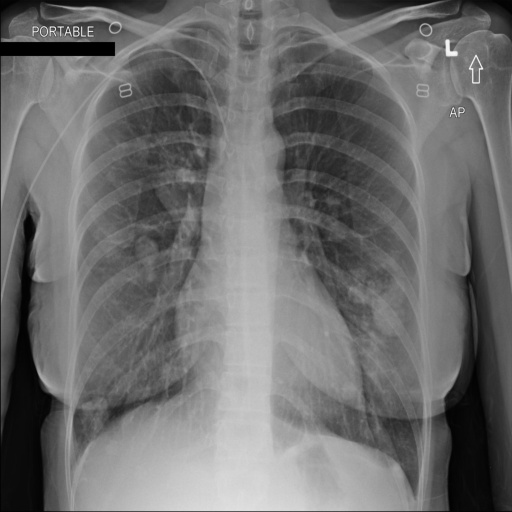

In [1]:
from IPython.display import Image, display

# 替換成你的圖片路徑
img_path = '/media/Siamese-Diffusion/data/cvc_train_images/1.2.826.0.1.3680043.8.498.10008193698745944671737283077530844393.jpg'

display(Image(filename=img_path, width=400))

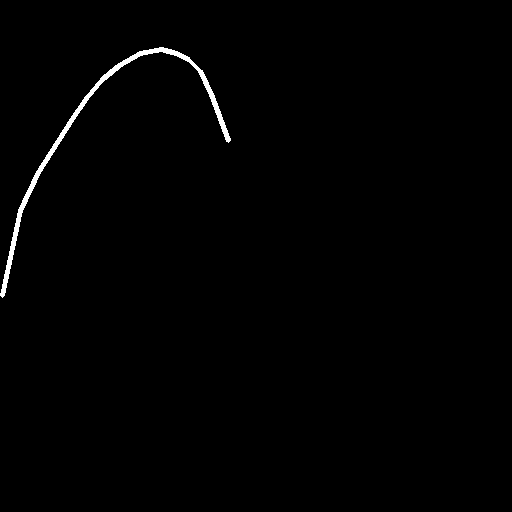

In [2]:
from IPython.display import Image, display

# 替換成你的圖片路徑
img_path = '/media/Siamese-Diffusion/data/cvc_masks/1.2.826.0.1.3680043.8.498.10008193698745944671737283077530844393.png'

display(Image(filename=img_path, width=400))

In [5]:
import sys
import os

# 將當前目錄加入 Python 搜尋路徑
sys.path.append(os.getcwd())

import torch
from cldm.model import create_model, load_state_dict

# 配置路徑 (請確認與你環境一致)
CKPT_PATH = "./merged_model.ckpt"
CONFIG_PATH = './models/cldm_v15.yaml'
DEVICE = "cuda"

# 1. 載入模型
model = create_model(CONFIG_PATH).cpu()
model.load_state_dict(load_state_dict(CKPT_PATH, location='cpu'), strict=False)
model.to(DEVICE)
model.eval()

# 2. 模擬一個假的輸入資料 (Batch Size = 1)
# 假設影像大小為 512x512
dummy_batch = {
    "jpg": torch.zeros((1, 512, 512, 3)).to(DEVICE), # 模擬原圖
    "hint": torch.zeros((1, 512, 512, 3)).to(DEVICE), # 模擬 ControlNet 遮罩
    "txt": ["a central venous catheter in a chest x-ray"] # 模擬 Prompt
}

# 3. 執行推論並抓取 Keys
with torch.no_grad():
    images = model.log_images(dummy_batch, N=1, ddim_steps=5) # 步數設小一點比較快
    
print("\n" + "="*30)
print("✅ 成功抓取到 Images 字典！")
print("目前所有的 Key 名稱為：")
for i, key in enumerate(images.keys()):
    print(f"{i+1}. {key}")
print("="*30)

ModuleNotFoundError: No module named 'cldm'